<a href="https://colab.research.google.com/github/nagamamo/machine_learning_for_finance/blob/main/5_capm_using_lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**5　Capital Asset Pricing Model using Lasso: Theory and Practice**

In this example, we compare the expected returns and risk premiums of two stocks by calculating their beta values ​​using Ordinary Least Squares (OLS) and Machine Learning (Lasso). We use the stock prices of Toyota (7203.JP), one of the world largest vehicle manufacturer listed on the Tokyo Stock Exchange, and Honda (7267.JP), which is facing the need to restructure its business from EV production.

**1. Import Libraries**

To begin this implementation, we import seven libraries: ***pandas*** and ***numpy*** for statistical analysis and numerical calculations, ***matplotlib*** for graph creation, and ***sklearn*** for OLS and Lasso regression analysis.

In [1]:
#[1-1]Import General Libraries
import pandas as pd #Library for Data management 1
import numpy as np #Library for Data management 2
import matplotlib.pyplot as plt #Library for data visualization
import datetime

In [2]:
#[1-2]Import Libraries for Machine Learning
from sklearn.model_selection import train_test_split #Library for splitting data into training data and test data
from sklearn.linear_model import LinearRegression #Library for Ordinary Least Squares(OLS)
from sklearn.linear_model import LassoCV #Libraries for cross-validation

**2. Data Management**

Next, we import dataset stored in the online storage Git-hub and name it *URL*.
Convert this *URL* to the ***pandas dataframe*** format and name it *data*. Converting a dataset into a ***pandas dataframe*** format is a core requirement for becoming proficient in Python. In this example, the dependent variables are Toyota (7203.JP) and Honda (7267.JP) stock prices, the independent variables are the Nikkei Stock Average (^NKX), and four day-of-the-week dummy variables and eleven monthly dummy variables are employed as control variables.

In [3]:
#[2]Retrieving data
url = "https://github.com/nagamamo/data/blob/main/5_capm_lasso_data.csv?raw=true"#Obtaining CSV data from an online strage Git-hub
data = pd.read_csv(url)#Converting acquired dataset (url) into pandas dataframe data (data)
data["Date"] = pd.to_datetime(data["Date"], errors='coerce') #Convert date information to index, coercing unparseable dates to NaT
df = data.set_index("Date")#Convert date information to index
df.head()

,Toyota,Honda,Nikkei,Mon,Tue,Wed,Thr,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov
Date,,,,,,,,,,,,,,,,,,
2015-01-06,-2.757,-2.182,-3.019,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
2015-01-07,1.465,-0.811,0.013,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
2015-01-08,1.984,1.927,1.669,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
2015-01-09,0.729,1.145,0.178,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2015-01-13,-1.184,-0.027,-0.640,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0


**3. Data Preprocessing**

In lines 1 and 2 below, we change the column names of the *pandas dataframe* data imported in the previous cells. Next, we will preprocess the data. ***sklearn*** cannot handle a *pandas dataframe* array data as a dataset. This data array must be converted to *ndarray* array. By adding ".value" to the end of the data column name, you can convert the *pandas dataframe* to the *ndarray*.

In [4]:
#[3]Data Preprocessing
company_list=['Toyota','Honda','Nikkei','Mon','Tue','Wed','Thu','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov'] #Redefine variable names
df.columns = company_list
X = df[['Nikkei','Mon','Tue','Wed','Thu','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']].values #Defining independnet variables and transforming data arrays
Y = df[['Toyota']].values #Defining dependnet variables and transforming data arrays
#Y = df[['Honda']].values #Defining dependnet variables and transforming data arrays

**4. Estimating Beta: OLS**

The following source code estimates Toyota's beta using OLS regression analysis, using the daily stock return of Toyota (7203.JP) and Honda (7267.JP), the Nikkei Average Stock Index, four week dummy variables and eleven monthly dummy variables. A two-variable regression analysis excluding control variables allows for direct estimation of the beta value β. Therefore, this empirical model is called the **Single-factor Model**.

Taking look at the result, the beta value is 0.927 for Toyota, and the all the parameters of four week dummy and eleven monthly dummy variables are not "0" and coefficient biases therefore remain, which indicates that the control variables have a significant impact on future predictions for this individual stock price.


In [5]:
#[4]Estimating Beta by OLS: Toyota & Honda
ols = LinearRegression()
X1=np.delete(X,0,0)
Y1=np.delete(Y,0,0)
ols.fit(X1, Y1)
print('β =  %.4f'% ols.coef_[0][0])
print(f"Coef: {ols.coef_:}")
print('intercept = %.4f'% ols.intercept_[0])
print('R_squared = %.4f '% ols.score(X1,Y1))

β =  0.9525
Coef: [[ 0.95245741  0.00961146  0.13446713  0.19152739  0.00797454 -0.08537566
  -0.17226459 -0.07167823 -0.18107356 -0.23977805 -0.14146777 -0.06325092
  -0.13726039 -0.10347377 -0.14521694 -0.15806362]]
intercept = 0.0637
R_squared = 0.5293 


**5. Estimating Beta: ML (Lasso)**

Next, we estimate the beta values ​​using Lasso regression. Lasso regression additionally employs a penalty term to the mean squared error (MSE) and multiplying it by a regularization parameter, which controls the amount of regularization applied. In the case of Lasso regression, this regularization is called L1 regularization. Increasing the value of regularization parameter increases the penalty, shrinking the coefficients toward zero. This can significantly reduce (or even completely eliminate) the importance of some features in the model, resulting in automatic feature selection. Conversely, decreasing the value of regularization parameter reduces the impact of the penalty and retains more features in the model.


The regularization parameter plays an important role in controlling the complexity of the model. Larger values ​​of this parameter result in a stronger penalty and a simpler model, but at the same time, there is a risk of oversimplification.

On the other hand, smaller values ​​of regularization parameter result in a more complex model and increase the likelihood of overfitting. Cross-validation is commonly used to find the optimal value, which maximizes model performance and enables reliable predictions.

L1 regularization penalizes the regression coefficients, eliminating unnecessary variables and improving model interpretability. This reduces data noise and leads to more reliable predictions.

Looking at the estimation results, the beta value itself ​​is almost the same as that estimated using OLS. On the other hand, we can see that **two of the four control variables are omitted, reducing the coefficient bias**. This means that when making future predictions for this stock price, we can use a model with a small coefficient bias.

In [6]:
#[5]Estimating Beta by ML (Lasso): Toyota and Honda
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1,random_state=0)#Splitting training data and test data
#machine = Lasso(alpha=0.1)#Definition of ML estimation method
machine = LassoCV(cv=20,  random_state=0).fit(X, Y.ravel())#Definition of ML estimation method
machine.fit(X_train,Y_train.ravel())#Fitting
Y_train_pred=machine.predict(X_train)#Predictions using training data
Y_test_pred=machine.predict(X_test)#Predictions using test data
print('β =  %.4f'% machine.coef_[0])
print(f"Coef: {machine.coef_:}")
print(f"Intercept: {machine.intercept_:}")
print(f"R_squared: {machine.score(X_test, Y_test):.6f}")
print(f"alpha: {machine.alpha_:}")

β =  0.9505
Coef: [ 0.95051774 -0.          0.08406116  0.14869622 -0.         -0.
 -0.          0.         -0.         -0.         -0.          0.
 -0.          0.         -0.         -0.        ]
Intercept: -0.028734388995435678
R_squared: 0.524260
alpha: 0.008920783430399124


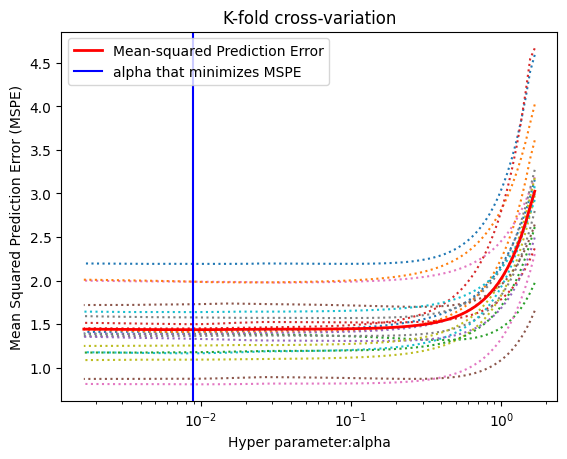

In [7]:
#[6]Visualizing Lasso Regression Results
plt.semilogx(machine.alphas_, machine.mse_path_, linestyle=":")
plt.plot(machine.alphas_,machine.mse_path_.mean(axis=-1),color="red",label="Mean-squared Prediction Error",linewidth=2,)
plt.axvline(machine.alpha_, linestyle="solid", color="blue", label="alpha that minimizes MSPE")
plt.xlabel("Hyper parameter:alpha")
plt.ylabel("Mean Squared Prediction Error (MSPE)")
plt.title("K-fold cross-variation")
plt.legend()